# Dataset Exploration & Label Creation: FINDHR Semi-synthetic CVs

This notebook is used to understand the structure of the FINDHR semi-synthetic CV dataset, inspect distributions of sectors, experience, and sensitive attributes, and define a transparent rule-based labeling scheme for the screening task.

---


## Table of Contents

0. [Load needed Packages](#0-load-needed-packages)
1. [Load Metadata](#1-load-metadata)
2. [Basic Dataset Distributions](#2-basic-dataset-distributions)
3. [Inspect Raw CV Structure (JSON)](#3-inspect-raw-cv-structure-(json))
4. [Rule-Based Labeling Heuristic](#4-rule-based-labeling-heuristic)
5. [Save new Metadata CSV](#5-save-new-metadata-csv)


---


## 0. Load needed Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json
from sklearn.model_selection import train_test_split
from pathlib import Path
import sys

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

---
## 1. Load Metadata


The file `semisynthetic_cv_list.csv` contains one row per CV and provides sector, experience bucket, and one demographic attribute per CV.


In [3]:
DATA_ROOT = "../data/findhr_synthetic_cv_dataset-ver20251203"
META_PATH = f"{DATA_ROOT}/semisynthetic_cv/semisynthetic_cv_list.csv"
CV_DIR = f"{DATA_ROOT}/semisynthetic_cv/json_format"


df = pd.read_csv(META_PATH)
df.head()

,filename,sector,years_professional_experience,demographic_var,demographic_var_value,id,gen_id
0,6_synthetic_cv.json,Business and administration,4 years or less of experience,perceived_foreign,No,1745913597519647_19,1745913597519647
1,15_synthetic_cv.json,Business and administration,4 years or less of experience,perceived_foreign,No,1745913597519647_9,1745913597519647
2,30_synthetic_cv.json,Business and administration,4 years or less of experience,LGBTQ_status,No,1745913087080016_7,1745913087080016
3,31_synthetic_cv.json,Business and administration,4 years or less of experience,disability,No,1745912960680944_12,1745912960680944
4,91_synthetic_cv.json,Business and administration,4 years or less of experience,minority,No,1745913883701383_7,1745913883701383


---
## 2. Basic Dataset Distributions

In this section, I inspect the distribution of job sectors, experience buckets, and demographic variables using the metadata file.


In [4]:
sector_order = df["sector"].value_counts().index

sector_exp_counts = pd.crosstab(
    df["sector"],
    df["years_professional_experience"]
)

sector_exp_counts = sector_exp_counts.loc[sector_order]

sector_exp_counts

years_professional_experience,10-14 years of experience,15+ years of experience,4 years or less of experience,5-9 years of experience
sector,,,,
Business and administration,20,258,67,116
Clerical support,0,225,213,20
Science and engineering,0,104,182,17
ICT,0,15,145,56
Sales,0,112,96,0
"Legal, social and cultural",0,0,84,0


In [5]:
exp_order = [
    "4 years or less of experience",
    "5-9 years of experience",
    "10-14 years of experience",
    "15+ years of experience"
]
sector_exp_counts = sector_exp_counts[exp_order]

In [6]:
df["sector"] = pd.Categorical(
    df["sector"],
    categories=sector_order,
    ordered=True
)

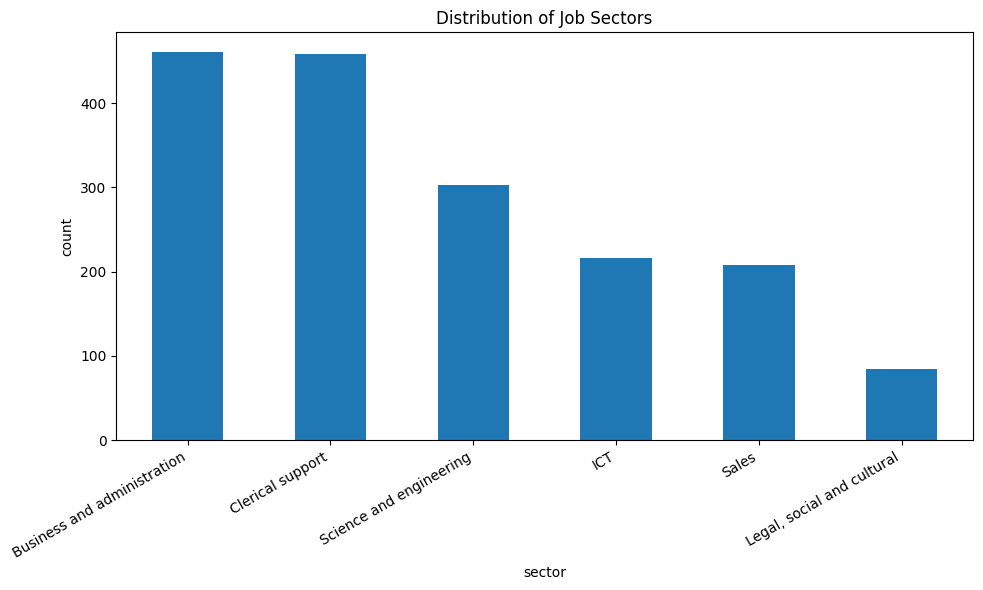

In [7]:
plt.figure(figsize=(10, 6))

sector_counts = df["sector"].value_counts()

sector_counts.plot(kind="bar")

plt.title("Distribution of Job Sectors")
plt.ylabel("count")
plt.xticks(rotation=30, ha="right") 
plt.tight_layout()
plt.show()

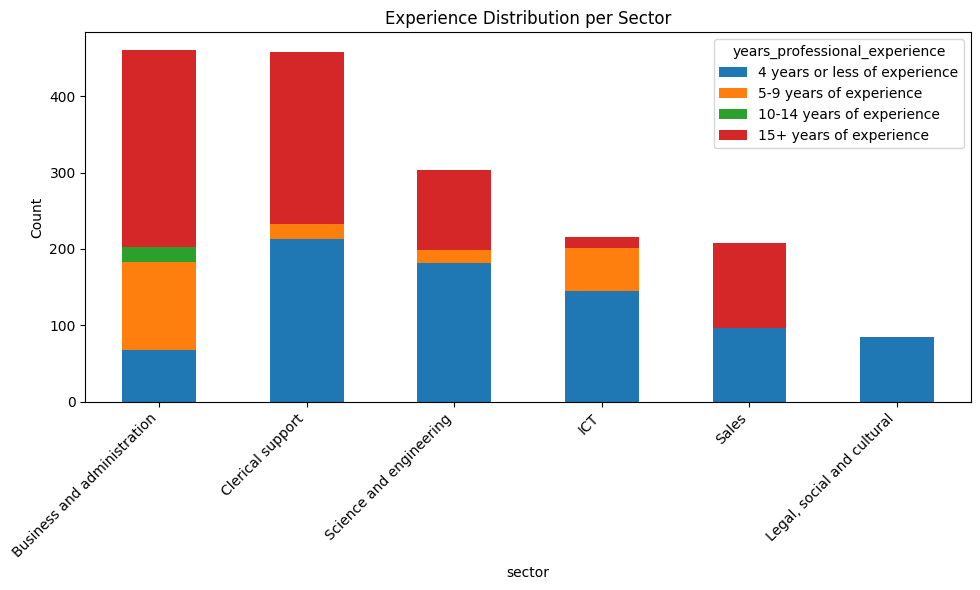

In [8]:
sector_exp_counts.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Experience Distribution per Sector")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
colors = [
    "#c9e1f8",  # 4 years or less (very light)
    "#9ecae1",  # 5–9 years
    "#4292c6",  # 10–14 years
    "#084594"   # 15+ years (dark)
]

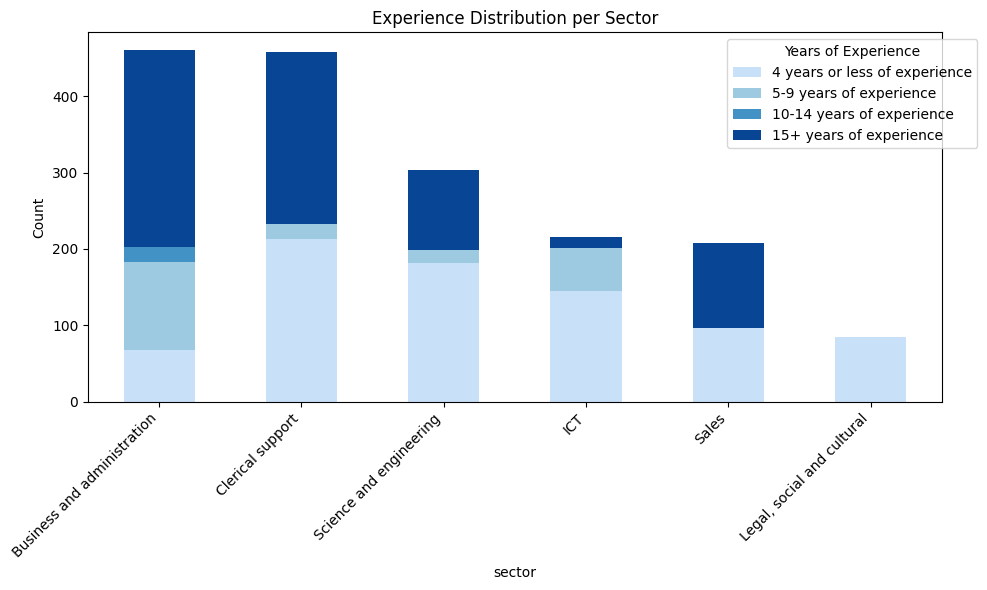

In [10]:
REP_DIR = PROJECT_ROOT / "reports"
REP_DIR.mkdir(exist_ok=True)

save_path = REP_DIR / "experience_distribution_per_sector.png"

sector_exp_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=colors
)

plt.title("Experience Distribution per Sector")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Years of Experience", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig(
    save_path,
    dpi=300,            
    bbox_inches="tight"
)
plt.show()

In [11]:
sector_exp_counts["Total"] = sector_exp_counts.sum(axis=1)
sector_exp_counts

years_professional_experience,4 years or less of experience,5-9 years of experience,10-14 years of experience,15+ years of experience,Total
sector,,,,,
Business and administration,67,116,20,258,461
Clerical support,213,20,0,225,458
Science and engineering,182,17,0,104,303
ICT,145,56,0,15,216
Sales,96,0,0,112,208
"Legal, social and cultural",84,0,0,0,84


In [12]:
df["demographic_var"].value_counts()

demographic_var
disability           381
perceived_foreign    301
minority             297
gender               270
LGBTQ_status         242
age                  180
religion              59
Name: count, dtype: int64

In [13]:
pd.crosstab(df["years_professional_experience"], df["demographic_var"])

demographic_var,LGBTQ_status,age,disability,gender,minority,perceived_foreign,religion
years_professional_experience,,,,,,,
10-14 years of experience,0,0,20,0,0,0,0
15+ years of experience,106,74,125,115,125,110,59
4 years or less of experience,110,106,149,117,150,155,0
5-9 years of experience,26,0,87,38,22,36,0


In [14]:
pd.crosstab(df["demographic_var"], df["demographic_var_value"])

demographic_var_value,41-50,<= 30,> 50,Christianity,Man,No,Woman,Yes
demographic_var,,,,,,,,
LGBTQ_status,0,0,0,0,0,227,0,15
age,46,106,28,0,0,0,0,0
disability,0,0,0,0,0,381,0,0
gender,0,0,0,0,129,0,141,0
minority,0,0,0,0,0,149,0,148
perceived_foreign,0,0,0,0,0,265,0,36
religion,0,0,0,59,0,0,0,0


In [15]:
pd.crosstab(df["sector"], df["demographic_var"])

demographic_var,LGBTQ_status,age,disability,gender,minority,perceived_foreign,religion
sector,,,,,,,
Business and administration,77,46,103,65,84,65,21
Clerical support,69,54,86,77,82,68,22
Science and engineering,47,32,71,56,42,55,0
ICT,23,15,48,38,37,55,0
Sales,26,15,50,34,34,33,16
"Legal, social and cultural",0,18,23,0,18,25,0


In [16]:
pd.crosstab(
    [df["sector"], df["years_professional_experience"]],
    df["demographic_var"]
)

demographic_var                                            LGBTQ_status  age  \
sector                      years_professional_experience                      
Business and administration 10-14 years of experience                 0    0   
                            15+ years of experience                  34   46   
                            4 years or less of experience            17    0   
                            5-9 years of experience                  26    0   
Clerical support            15+ years of experience                  33   28   
                            4 years or less of experience            36   26   
                            5-9 years of experience                   0    0   
Science and engineering     15+ years of experience                  21    0   
                            4 years or less of experience            26   32   
                            5-9 years of experience                   0    0   
ICT                         15+ years of experience                   0    0   
                            4 years or less of experience            23   15   
                            5-9 years of experience                   0    0   
Sales                       15+ years of experience                  18    0   
                            4 years or less of experience             8   15   
Legal, social and cultural  4 years or less of experience             0   18   

demographic_var                                            disability  gender  \
sector                      years_professional_experience                       
Business and administration 10-14 years of experience              20       0   
                            15+ years of experience                38      43   
                            4 years or less of experience          16       0   
                            5-9 years of experience                29      22   
Clerical support            15+ years of experience                35      37   
                            4 years or less of experience          31      40   
                            5-9 years of experience                20       0   
Science and engineering     15+ years of experience                25      20   
                            4 years or less of experience          29      36   
                            5-9 years of experience                17       0   
ICT                         15+ years of experience                 0       0   
                            4 years or less of experience          27      22   
                            5-9 years of experience                21      16   
Sales                       15+ years of experience                27      15   
                            4 years or less of experience          23      19   
Legal, social and cultural  4 years or less of experience          23       0   

demographic_var                                            minority  \
sector                      years_professional_experience             
Business and administration 10-14 years of experience             0   
                            15+ years of experience              44   
                            4 years or less of experience        18   
                            5-9 years of experience              22   
Clerical support            15+ years of experience              44   
                            4 years or less of experience        38   
                            5-9 years of experience               0   
Science and engineering     15+ years of experience              19   
                            4 years or less of experience        23   
                            5-9 years of experience               0   
ICT                         15+ years of experience               0   
                            4 years or less of experience        37   
                            5-9 years of experience               0   
Sales                       15+ yea

---
## 3. Inspect Raw CV Structure (JSON)

To define the screening task and labeling heuristic, I inspect the JSON structure and relevant fields such as education, experience, and skills.

In [17]:
files = sorted(os.listdir(CV_DIR))

sample_path = os.path.join(CV_DIR, files[0])
with open(sample_path, "r") as f:
    cv_data = json.load(f)

cv_data.keys()

dict_keys(['education_background', 'professional_experience', 'skills', 'generation_parameters'])

In [18]:
cv_data

{'education_background': [{'institution': 'Autonomous University Of Barcelona',
   'start_date': 'January 2018',
   'end_date': 'December 2022',
   'degree': 'Bachelors Degree In Translation And Interpreting'}],
 'professional_experience': [{'institution': 'Cabinet Aci',
   'start_date': 'February 2017',
   'end_date': 'March 2017',
   'role': 'Stagiaire Juridique En Droit Pnal',
   'duration': '1 months',
   'duration_months': 1}],
 'skills': {'others': ['Agility',
   'Microsoft Word',
   'Management',
   'Omegat',
   'Cash Management',
   'Mandarin']},
 'generation_parameters': {'years_professional_experience': '4 years or less of experience',
  'disability': 'No',
  'generation_mode': 'synthetic',
  'sector': 'Legal, social and cultural'}}

In [19]:
empty_experience = 0
missing_duration = 0
empty_education = 0

for fn in os.listdir(CV_DIR):
    with open(os.path.join(CV_DIR, fn), "r") as f:
        cv = json.load(f)

    if len(cv.get("professional_experience", [])) == 0:
        empty_experience += 1

    if len(cv.get("education_background", [])) == 0:
        empty_education += 1

    for job in cv.get("professional_experience", []):
        if "duration_months" not in job:
            missing_duration += 1

print("CVs with no experience:", empty_experience)
print("CVs with no education:", empty_education)
print("Jobs missing duration_months:", missing_duration)


CVs with no experience: 0
CVs with no education: 0
Jobs missing duration_months: 0


---
## 4. Rule-Based Labeling Heuristic

In [20]:
sys.path.append(str(PROJECT_ROOT))
from src.labeling import build_labeled_metadata, label_diagnostics

# Build labels (rule-based policy)
df_full = build_labeled_metadata(
    metadata_df=df,
    cv_dir=Path(CV_DIR),
    group_cols=("sector", "years_professional_experience"),
    selectivity=0.30,
)

display(label_diagnostics(df_full).head(10))


,sector,years_professional_experience,total_candidates,shortlisted,shortlist_rate
0,Business and administration,10-14 years of experience,20,6,0.300000
1,Business and administration,15+ years of experience,258,78,0.302326
2,Business and administration,4 years or less of experience,67,20,0.298507
3,Business and administration,5-9 years of experience,116,35,0.301724
4,Clerical support,15+ years of experience,225,68,0.302222
5,Clerical support,4 years or less of experience,213,64,0.300469
6,Clerical support,5-9 years of experience,20,6,0.300000
7,Science and engineering,15+ years of experience,104,31,0.298077
8,Science and engineering,4 years or less of experience,182,55,0.302198
9,Science and engineering,5-9 years of experience,17,5,0.294118


In [21]:
df_full.head()

,filename,sector,years_professional_experience,demographic_var,demographic_var_value,id,gen_id,total_exp_months,n_jobs,n_degrees,n_skills,total_exp_months_norm,n_degrees_norm,n_skills_norm,n_jobs_norm,score_unbiased,label_unbiased
0,6_synthetic_cv.json,Business and administration,4 years or less of experience,perceived_foreign,No,1745913597519647_19,1745913597519647,4.0,1.0,1.0,4.0,0.010610,0.333333,0.333333,0.142857,0.131618,0
1,15_synthetic_cv.json,Business and administration,4 years or less of experience,perceived_foreign,No,1745913597519647_9,1745913597519647,6.0,1.0,2.0,5.0,0.015915,0.666667,0.416667,0.142857,0.196574,0
2,30_synthetic_cv.json,Business and administration,4 years or less of experience,LGBTQ_status,No,1745913087080016_7,1745913087080016,12.0,1.0,3.0,9.0,0.031830,1.000000,0.750000,0.142857,0.349407,1
3,31_synthetic_cv.json,Business and administration,4 years or less of experience,disability,No,1745912960680944_12,1745912960680944,45.0,1.0,1.0,12.0,0.119363,0.333333,1.000000,0.142857,0.266279,0
4,91_synthetic_cv.json,Business and administration,4 years or less of experience,minority,No,1745913883701383_7,1745913883701383,12.0,1.0,2.0,6.0,0.031830,0.666667,0.500000,0.142857,0.222251,0


### 4.1 Label Diagnostic

In [22]:
print("Overall class distribution:")
display(
    df_full["label_unbiased"]
        .value_counts(normalize=True)
        .rename("proportion")
        .round(3)
)

print("\nSelection rate per sector:")
display(
    pd.crosstab(
        df_full["sector"],
        df_full["label_unbiased"],
        normalize="index"
    ).round(3)
)

print("\nSelection rate per experience bucket:")
display(
    pd.crosstab(
        df_full["years_professional_experience"],
        df_full["label_unbiased"],
        normalize="index"
    ).round(3)
)

print("\nSelection rate per demographic value:")
display(
    pd.crosstab(
        df_full["demographic_var_value"],
        df_full["label_unbiased"],
        normalize="index"
    ).round(3)
)

print("\nSelection rate per demographic attribute:")
display(
    pd.crosstab(
        df_full["demographic_var"],
        df_full["label_unbiased"],
        normalize="index"
    ).round(3)
)


Overall class distribution:


label_unbiased
0    0.698
1    0.302
Name: proportion, dtype: float64


Selection rate per sector:


label_unbiased,0,1
sector,,
Business and administration,0.698,0.302
Clerical support,0.699,0.301
Science and engineering,0.700,0.300
ICT,0.694,0.306
Sales,0.697,0.303
"Legal, social and cultural",0.702,0.298



Selection rate per experience bucket:


label_unbiased,0,1
years_professional_experience,,
10-14 years of experience,0.700,0.300
15+ years of experience,0.697,0.303
4 years or less of experience,0.699,0.301
5-9 years of experience,0.699,0.301



Selection rate per demographic value:


label_unbiased,0,1
demographic_var_value,,
41-50,0.696,0.304
<= 30,0.698,0.302
> 50,0.643,0.357
Christianity,0.729,0.271
Man,0.713,0.287
No,0.711,0.289
Woman,0.645,0.355
Yes,0.658,0.342



Selection rate per demographic attribute:


label_unbiased,0,1
demographic_var,,
LGBTQ_status,0.653,0.347
age,0.689,0.311
disability,0.703,0.297
gender,0.678,0.322
minority,0.744,0.256
perceived_foreign,0.701,0.299
religion,0.729,0.271


In [23]:
df_full["label_name"] = df_full["label_unbiased"].map({0: "Rejected", 1: "Shortlisted"})
summary = (
    df_full
    .groupby(["sector", "years_professional_experience"])
    .agg(
        total_candidates=("label_unbiased", "count"),
        shortlisted=("label_unbiased", "sum")
    )
)

summary["shortlist_rate"] = summary["shortlisted"] / summary["total_candidates"]
summary.reset_index()

,sector,years_professional_experience,total_candidates,shortlisted,shortlist_rate
0,Business and administration,10-14 years of experience,20,6,0.300000
1,Business and administration,15+ years of experience,258,78,0.302326
2,Business and administration,4 years or less of experience,67,20,0.298507
3,Business and administration,5-9 years of experience,116,35,0.301724
4,Clerical support,15+ years of experience,225,68,0.302222
5,Clerical support,4 years or less of experience,213,64,0.300469
6,Clerical support,5-9 years of experience,20,6,0.300000
7,Science and engineering,15+ years of experience,104,31,0.298077
8,Science and engineering,4 years or less of experience,182,55,0.302198
9,Science and engineering,5-9 years of experience,17,5,0.294118


---
## 5. Save new Metadata CSV

 Save the newly created CSV with labels, demographics, score & experience bucket

In [24]:
PROCESSED_DIR = PROJECT_ROOT /"data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [26]:
df_model = df_full[[
    "filename",
    "sector",
    "years_professional_experience",
    "demographic_var",
    "demographic_var_value",
    "score_unbiased",
    "label_unbiased"
]].copy()

In [27]:
df_model = df_model.sort_values("filename").reset_index(drop=True)

In [28]:
save_path = os.path.join(PROCESSED_DIR, "cv_metadata_with_labels_unbiased.csv")
df_model.to_csv(save_path, index=False)

---
## 6. Create train/test split

In [29]:
from src.splitting import SplitConfig, split_train_val_test
import pandas as pd

df = pd.read_csv(PROCESSED_DIR / "cv_metadata_with_labels_unbiased.csv")

cfg = SplitConfig(train_frac=0.70, val_frac=0.10, test_frac=0.20, seed=12229942)
splits = split_train_val_test(df, cfg=cfg)

splits.to_csv(PROCESSED_DIR / "train_val_test_split_unbiased.csv", index=False)

In [31]:
display(splits["split"].value_counts())
merged = df.merge(splits, on="filename")
display(merged.groupby("split")["label_unbiased"].value_counts(normalize=True).round(3))


split
train    1210
test      347
val       173
Name: count, dtype: int64

split  label_unbiased
test   0                 0.703
       1                 0.297
train  0                 0.699
       1                 0.301
val    0                 0.682
       1                 0.318
Name: proportion, dtype: float64

In [32]:
df_full = pd.read_csv(PROCESSED_DIR / "cv_metadata_with_labels_unbiased.csv")
splits  = pd.read_csv(PROCESSED_DIR / "train_val_test_split_unbiased.csv")

merged = df_full.merge(splits, on="filename")

print("\nSector distribution per split:")
print(merged.groupby("split")["sector"].value_counts(normalize=True))


Sector distribution per split:
split  sector                     
test   Clerical support               0.265130
       Business and administration    0.262248
       Science and engineering        0.178674
       ICT                            0.123919
       Sales                          0.121037
       Legal, social and cultural     0.048991
train  Business and administration    0.266942
       Clerical support               0.265289
       Science and engineering        0.174380
       ICT                            0.124793
       Sales                          0.120661
       Legal, social and cultural     0.047934
val    Business and administration    0.271676
       Clerical support               0.260116
       Science and engineering        0.173410
       ICT                            0.127168
       Sales                          0.115607
       Legal, social and cultural     0.052023
Name: proportion, dtype: float64


### Dataset Version 1.0

- Samples: 1730
- Positive class: 30%
- Label construction: rule-based qualification score
- Split seed: 12229942
- Split ratio: 80/20/10
- Date frozen: 2026-02-27